# 實作DCGAN演算法，產生名人臉部

### 程式修改自[PyTorch DCGAN Tutorial](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)


## 載入套件


In [14]:
import glob, sys
from pathlib import Path
from typing import cast
from IPython.display import Image, display

import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import utils as vutils

## 設定參數


In [2]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 128  # 批量
image_size = 64
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 定義神經網路參數


In [3]:
nz = 100  # 生成神經網路雜訊維度
ngf = 64  # 生成神經網路濾波器個數
ndf = 64  # 判別神經網路濾波器個數
nc = 3  # 顏色通道

## 載入名人臉部資料集


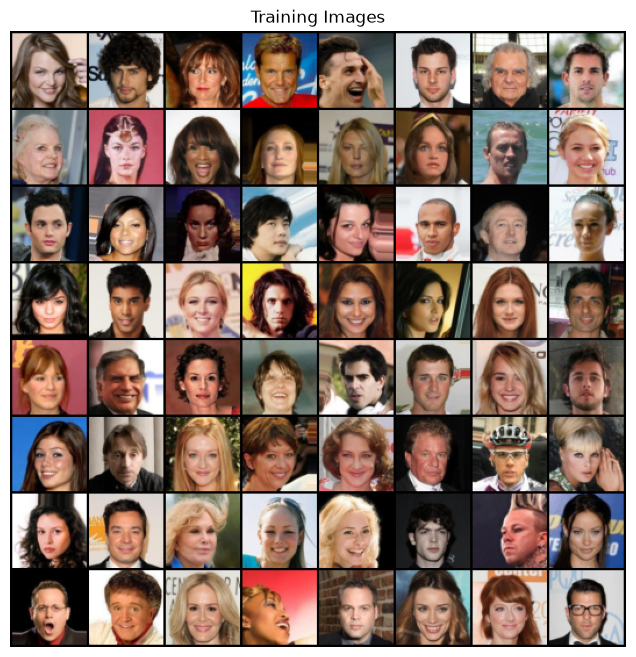

In [4]:
# 轉換
transform = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

# 訓練資料
dataset = datasets.ImageFolder(base_path / 'celeba_gan', transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 顯示圖檔
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(), (1, 2, 0)))

## 神經網路權重初始值


In [5]:
def weights_init(m: nn.Module) -> None:
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        cast(torch.Tensor, m.weight).data.normal_(0.0, 0.02)  # 卷積層權重初始值
    elif classname.find('BatchNorm') != -1:
        cast(torch.Tensor, m.weight).data.normal_(1.0, 0.02)  # Batch Normalization 層權重初始值
        cast(torch.Tensor, m.bias).data.fill_(0)

## 定義生成神經網路


In [6]:
class Generator(nn.Module):
    def __init__(self, nc: int = 3, nz: int = 100, ngf: int = ngf) -> None:
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        output = self.main(input)
        return output


netG = Generator().to(device)
netG.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding

## 定義判別神經網路


In [7]:
class Discriminator(nn.Module):
    def __init__(self, nc: int = 3, ndf: int = ndf) -> None:
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        output: torch.Tensor = self.main(input)
        return output.view(-1, 1).squeeze(1)


netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )

## 設定損失函數、優化器(optimizer)


In [8]:
# 設定損失函數
criterion = nn.BCELoss()

# 設定優化器(optimizer)
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

## 進行模型訓練


In [9]:
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
niter = 10
# 模型訓練
for epoch in range(niter):
    data: torch.Tensor
    for i, data in enumerate(dataloader, 0):
        ########################################################
        # (1) 判別神經網路: maximize log(D(x)) + log(1 - D(G(z)))
        #######################################################
        # 訓練真實資料
        netD.zero_grad()
        real_cpu = data[0].to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), real_label, device=device)

        output: torch.Tensor = netD(real_cpu)
        errD_real: torch.Tensor = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # 訓練假資料
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake: torch.Tensor = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach())
        errD_fake: torch.Tensor = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        ########################################################
        # (2) 判別神經網路: maximize log(D(G(z)))
        #######################################################
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG: torch.Tensor = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        if i % 200 == 0:
            print(
                f'[{epoch + 1}/{niter}][{i}/{len(dataloader)}] '
                f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}'
            )
            vutils.save_image(real_cpu, 'gan_face_output/real_samples.png', normalize=True)
            fake = netG(fixed_noise)
            vutils.save_image(fake.detach(), f'gan_face_output/fake_samples_epoch_{epoch:03d}.png', normalize=True)
    torch.save(netG.state_dict(), f'gan_face_weights/netG_epoch_{epoch}.pth')
    torch.save(netD.state_dict(), f'gan_face_weights/netD_epoch_{epoch}.pth')

[1/10][0/1583] Loss_D: 2.4032 Loss_G: 4.2204 D(x): 0.4148 D(G(z)): 0.6528 / 0.0270
[1/10][200/1583] Loss_D: 0.4415 Loss_G: 5.5885 D(x): 0.8452 D(G(z)): 0.1843 / 0.0065
[1/10][400/1583] Loss_D: 0.7606 Loss_G: 3.0522 D(x): 0.6687 D(G(z)): 0.1702 / 0.0693
[1/10][600/1583] Loss_D: 0.7234 Loss_G: 2.9153 D(x): 0.6801 D(G(z)): 0.1651 / 0.0942
[1/10][800/1583] Loss_D: 0.6042 Loss_G: 4.6778 D(x): 0.8357 D(G(z)): 0.2571 / 0.0190
[1/10][1000/1583] Loss_D: 0.4619 Loss_G: 1.7925 D(x): 0.7884 D(G(z)): 0.1213 / 0.2940
[1/10][1200/1583] Loss_D: 1.1113 Loss_G: 7.3471 D(x): 0.9734 D(G(z)): 0.5833 / 0.0020
[1/10][1400/1583] Loss_D: 0.5244 Loss_G: 2.8608 D(x): 0.7102 D(G(z)): 0.0792 / 0.0980
[2/10][0/1583] Loss_D: 1.0789 Loss_G: 7.1715 D(x): 0.9300 D(G(z)): 0.5662 / 0.0024
[2/10][200/1583] Loss_D: 0.4184 Loss_G: 3.7665 D(x): 0.8896 D(G(z)): 0.2290 / 0.0336
[2/10][400/1583] Loss_D: 0.5391 Loss_G: 4.4056 D(x): 0.8830 D(G(z)): 0.2984 / 0.0194
[2/10][600/1583] Loss_D: 0.5414 Loss_G: 4.0871 D(x): 0.8329 D(G(z)

## 新資料預測


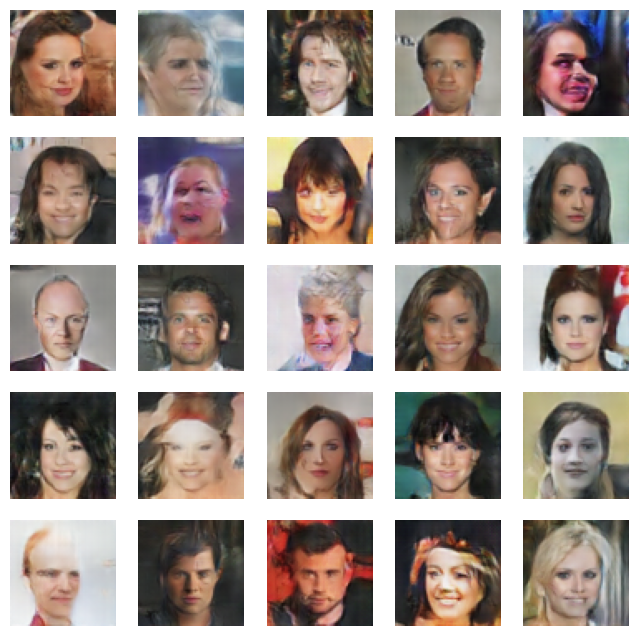

In [ ]:
batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
# 產生圖像，clamp 使像素值介於 [-1, 1] 之間
fake_images: torch.Tensor = netG(fixed_noise).clamp(min=-1, max=1)
fake_images_np = fake_images.cpu()
fake_images_np = fake_images_np.reshape(-1, 3, image_size, image_size)
fake_images_np = torch.permute(fake_images_np, (0, 2, 3, 1)).detach().numpy()
fake_images_np = (fake_images_np + 1) * 0.5  # 使像素值介於 [0, 1] 之間
R, C = 5, 5
plt.figure(figsize=(8, 8))
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.axis('off')
    plt.imshow(fake_images_np[i])
plt.show()

## 顯示 GIF 檔


In [11]:
# 產生 GIF 檔
anim_file = 'gan_face_output/dcgan.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('gan_face_output/fake_samples*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        cast(imageio.core.format.Format.Writer, writer).append_data(image)

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_35814/3349507338.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


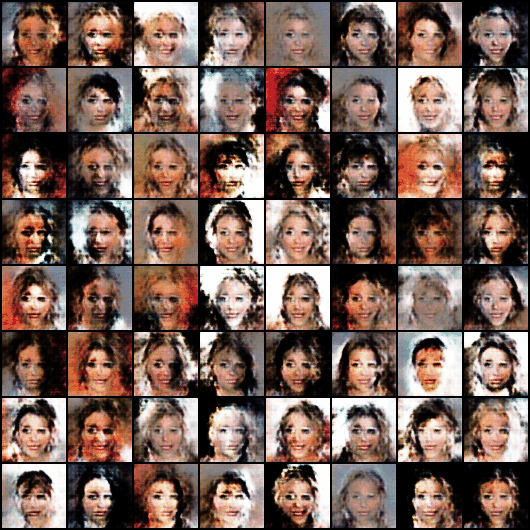

In [15]:
# 顯示anim_file圖檔，並能循環播放
display(Image(filename=anim_file))

In [12]:
# 載入權重
netD.load_state_dict(torch.load('gan_face_weights/netD_epoch_9.pth'))
netG.load_state_dict(torch.load('gan_face_weights/netG_epoch_9.pth'))

<All keys matched successfully>